In [157]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from joblib import dump
from h5py import File
from os.path import exists

import csiborgtools
from scipy.stats import norm

%matplotlib inline
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
fpath = "/mnt/extraspace/rstiskalek/catalogs/PV_compilation.hdf5"
# fpath = "/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_TFR.hdf5"

with File(fpath, 'r') as f:
    # mag  = f["w1"][...]
    # eta = f["lgWmxi"][...] - 2.5
    # Qw = f["Qw"][...]
    # RA = f["RA"][...] * 360 / 24
    # DEC = f["DE"][...]

    # zCMB = f["Vcmb"][...] / 299792.458
    RA_2MTF = f["2MTF/RA"][...]
    DEC_2MTF = f["2MTF/DEC"][...]

    # m = (mag > 5) & (Qw == 5) & (eta > -0.3)
    # mag, eta = mag[m], eta[m]
    # RA_CF4, DEC_CF4 = RA[m], DEC[m]

# RA = f["2MTF/RA"][...]
# DEC = f["2MTF/DEC"][...]

array([ 1000.        ,  1000.        ,  1000.        ,  1000.        ,
        1000.        ,  1000.        ,  1000.        ,  1000.        ,
        1000.        ,  1000.        ,  3111.11111111,  3111.11111111,
        3111.11111111,  3111.11111111,  3111.11111111,  3111.11111111,
        3111.11111111,  3111.11111111,  3111.11111111,  3111.11111111,
        5222.22222222,  5222.22222222,  5222.22222222,  5222.22222222,
        5222.22222222,  5222.22222222,  5222.22222222,  5222.22222222,
        5222.22222222,  5222.22222222,  7333.33333333,  7333.33333333,
        7333.33333333,  7333.33333333,  7333.33333333,  7333.33333333,
        7333.33333333,  7333.33333333,  7333.33333333,  7333.33333333,
        9444.44444444,  9444.44444444,  9444.44444444,  9444.44444444,
        9444.44444444,  9444.44444444,  9444.44444444,  9444.44444444,
        9444.44444444,  9444.44444444, 11555.55555556, 11555.55555556,
       11555.55555556, 11555.55555556, 11555.55555556, 11555.55555556,
      

In [169]:
!rm /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/*


reader = csiborgtools.read.Carrick2015Field()
velocity = reader.velocity_field()
boxsize = csiborgtools.simname2boxsize("Carrick2015")

# mean_mag = 10.31
# std_mag = 0.83
mean_mag, std_mag= 13.13071407140714, 0.8
mean_eta, std_eta = 0.0, 0.1

a_TF = -20.75
b_TF = -5
c_TF = 3

h = 1.0
beta = 0.0
nrepeat_calibration = 2
kmax = 1
seed = 43

a_TF_dipole_mag = 0.06
a_TF_dipole_l =150
a_TF_dipole_b = 30

nsamples = 3000

kmax = 10
nrepeat_per_size = 10
zcmb_max = 0.055001
nsamples = np.repeat(np.linspace(1000, 20000, kmax, dtype=int), nrepeat_per_size)
fname_table = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock_tables/Carrick2MTFmock_table_{zcmb_max}.txt"

if nsamples is not None and not isinstance(nsamples, int):
    if exists(fname_table):
        raise ValueError(f"Table already exists: {fname_table}")

    np.savetxt(fname_table, nsamples)
    print(f"Saving the table to `{fname_table}`")

if isinstance(nsamples, int):
    nsamples = [nsamples]


for k in trange(kmax * nrepeat_per_size):
    gen = np.random.default_rng(seed)
    if nsamples is None:
        RA = RA_2MTF
        DEC = DEC_2MTF
    else:
        nsamples_current = nsamples[k]
        print(f"Generating {nsamples_current} samples")
        RA = gen.uniform(0, 360, nsamples_current)
        DEC = np.rad2deg(np.arcsin(gen.uniform(-1, 1, nsamples_current)))

    mock, truths = csiborgtools.flow.mock_Carrick2MTF(
        velocity, boxsize, RA, DEC,
        Vext_mag=250, Vext_l=300, Vext_b=-4,
        a_TF_dipole_mag=a_TF_dipole_mag, a_TF_dipole_l=a_TF_dipole_l, a_TF_dipole_b=a_TF_dipole_b,
        mean_mag=mean_mag, std_mag=std_mag,
        mean_eta=mean_eta, std_eta=std_eta,
        h=h, a_TF=a_TF, b_TF=b_TF, c_TF=c_TF, sigma_TF=0.3,
        sigma_cal=0.2, sigma_v=250,
        nrepeat_calibration=nrepeat_calibration, beta=beta,
        calibration_max_percentile=None, calibration_rand_fraction=None,
        seed=seed, verbose=True, return_truths=True,)
    seed += 1

    fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed{k}.hdf5"  # noqa
    print("Saving to ", fname)
    with File(fname, 'w') as f:
        for key in mock.keys():
            f.create_dataset(key, data=mock[key])

    fname_truths = fname.replace(".hdf5", "_truths.pkl")
    dump(truths, fname_truths)

Saving the table to `/mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock_tables/Carrick2MTFmock_table_0.055001.txt`


  0%|          | 0/100 [00:00<?, ?it/s]

Generating 1000 samples
11 galaxies are above 150 Mpc/h.
Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed0.hdf5
Generating 1000 samples
15 galaxies are above 150 Mpc/h.
Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed1.hdf5


  4%|▍         | 4/100 [00:00<00:08, 11.89it/s]

Generating 1000 samples
19 galaxies are above 150 Mpc/h.
Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed2.hdf5
Generating 1000 samples
14 galaxies are above 150 Mpc/h.
Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed3.hdf5
Generating 1000 samples
20 galaxies are above 150 Mpc/h.
Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed4.hdf5
Generating 1000 samples
16 galaxies are above 150 Mpc/h.
Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed5.hdf5
Generating 1000 samples


...

Generating 20000 samples
286 galaxies are above 150 Mpc/h.
Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed95.hdf5
Generating 20000 samples


 98%|█████████▊| 98/100 [00:07<00:00,  8.74it/s]

281 galaxies are above 150 Mpc/h.
Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed96.hdf5
Generating 20000 samples
284 galaxies are above 150 Mpc/h.
Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed97.hdf5
Generating 20000 samples


100%|██████████| 100/100 [00:07<00:00, 12.99it/s]

294 galaxies are above 150 Mpc/h.
Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed98.hdf5
Generating 20000 samples
300 galaxies are above 150 Mpc/h.
Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed99.hdf5


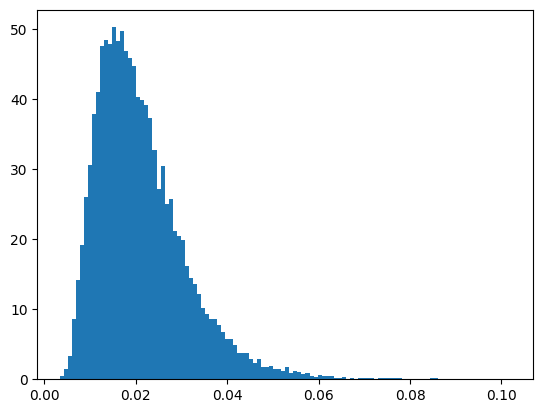

In [166]:
plt.figure()
plt.hist(mock["r"]* 100 / 299792.458, bins="auto", density=1)
# plt.hist(zCMB, bins="auto", histtype='step', density=1)
# plt.xlim(0,0.05)

plt.show()